In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# MNE
import mne
from mne.preprocessing import ICA
from mne_icalabel import label_components
from mne.annotations import Annotations
from mne.io import read_raw_fif
from mne.viz import plot_topomap
from mne.time_frequency import psd_array_welch

# Statistics
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import ttest_ind

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc


In [29]:
import torch
print(torch.__version__)
print("MPS available?", torch.backends.mps.is_available())

2.7.1
MPS available? True


### Config — paths & processing constants  

All hard-coded parameters live in one place so you (or a colleague) can
re-run the notebook on another machine by editing a single cell.

* **paths** – BIDS root and sub-folders inside `derivatives/`
* **data**  – recording constants reused later (montage, sfreq, etc.)
* **ica**   – method & hyper-params; change here to compare algorithms
* **reject** – thresholds that tag bad ICs automatically
* **features** – what spectral bands & window length to extract
* **model** – a first classifier + CV split; purely exploratory


In [30]:
CONFIG = dict(

    # ---------- paths ----------------------------------------------------
    paths = dict(
        bids_root   = Path("../bids_dataset"),
        deriv_root  = Path("../bids_dataset/derivatives"),
        filt_dir    = Path('../bids_dataset/derivatives/filt_crop/sub-lina/ses-02/eeg/'),
        ica_dir     = Path("../bids_dataset/derivatives/ica_clean/sub-lina/ses-02/eeg/"),
        annot_dir   = Path("../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/"),
        timing_csv  = Path("../audio-timeline.csv"),
    ),

    # ---------- recording constants --------------------------------------
    data = dict(
        sfreq       = 125.0,                      # Hz
        eeg_ch      = ["Fp1","Fp2","C3","C4","T7","T8",
                       "O1","O2","F3","F4","Fz","Pz","P3","P4"],
        montage     = "standard_1020",
        n_blocks    = 21,
    ),

    # ---------- ICA parameters -------------------------------------------
    ica = dict(
        method         = "picard",    # "fastica" | "picard" | "infomax"
        n_components   = 0.99,        # keep 99 % of variance
        random_state   = 42,
        max_iter       = 500,
        decim          = 2            # 125 Hz → 62.5 Hz for fitting
    ),

    # ---------- auto-reject thresholds (z-score in IC space) -------------
    reject = dict(
        eog_z     = 3.0,     # eye blinks
        emg_z     = 3.0,     # muscle
        slow_z    = 3.0      # slow drifts
    ),
)

# ------------------------------------------------------------------------
# create sub-folders if they don’t exist
for p in CONFIG["paths"].values():
    if p.suffix == "":          # skip the CSV path; only create dirs
        p.mkdir(parents=True, exist_ok=True)

print("Config updated – paths for annotations and timeline CSV added 🚀")

Config updated – paths for annotations and timeline CSV added 🚀


## 1. Loading the 21 filtered & cropped blocks

Before any additional processing we first bring the twenty pre-filtered /
cropped recordings into memory.  
At this stage **projectors remain OFF** so the data are identical to the files
written by 04_Lina_restart_with_MNE (`*_flt-crop_raw.fif`).


In [31]:
# Gather the expected *_desc-filtcrop_eeg.fif files (BIDS-compliant)
filt_dir = CONFIG["paths"]["filt_dir"]

blk_paths = sorted(filt_dir.glob("sub-lina_ses-02_task-musicphrases-sing_run-*_desc-filtcrop_eeg.fif"))
assert len(blk_paths) == CONFIG["data"]["n_blocks"], (
    f"Expected {CONFIG['data']['n_blocks']} blocks, found {len(blk_paths)}."
)

raw_blocks = []
for fpath in blk_paths:
    print(f"Reading {fpath.name} …", end=" ")
    raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
    raw_blocks.append(raw)
    print("✓")

print(f"\nLoaded {len(raw_blocks)} blocks. Projectors are currently OFF.")


Reading sub-lina_ses-02_task-musicphrases-sing_run-01_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrases-sing_run-02_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrases-sing_run-03_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrases-sing_run-04_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrases-sing_run-05_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrases-sing_run-06_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrases-sing_run-07_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrases-sing_run-08_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrases-sing_run-09_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrases-sing_run-10_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrases-sing_run-11_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrases-sing_run-12_desc-filtcrop_eeg.fif … ✓
Reading sub-lina_ses-02_task-musicphrase

### 1a · Why we switch **ON** the average-reference projection

Each `.fif` block already contains a *projector* that re-references the data to
the **common average** (CAR).  Up to this point we kept that projector **OFF**
to ensure the raw voltages from the previous notebook were preserved during
filtering/cropping.  Turning the projector **ON** now is critical for three
reasons:

1. **Signal centring**   
   Referencing every channel to the grand mean neutralises slow offsets caused
   by unequal electrode impedances or amplifier drift.  This flattens the
   baseline and yields cleaner butterfly plots and topomaps.

2. **Better ICA decomposition**   
   ICA assumes that sources mix *linearly* and with zero-mean time courses.
   Applying the CAR before decomposition improves the separation of ocular,
   cardiac and myogenic components, making automatic IC labelling more
   reliable.

3. **Pipeline consistency**   
   Most EEG-to-text decoding papers perform ICA on average-referenced data.
   Activating the projector now keeps our workflow aligned with that
   literature and prevents accidental mixing of referenced and
   non-referenced epochs later on.

> **Note:** `raw.apply_proj()` is *idempotent*—once the projector is applied,
> calling it again will have no additional effect as the projection matrix is
> removed from `raw.info["projs"]`.


In [32]:
for idx, raw in enumerate(raw_blocks):
    if not raw.info["projs"]:
        raise RuntimeError(f"Block {idx:02d} has no projector defined.")
    raw.apply_proj(verbose=False)

print(f"✅  Average-reference projection applied to {len(raw_blocks)} blocks.")

✅  Average-reference projection applied to 21 blocks.


#### Where does the stored **common-average reference (CAR)** come from?

The projector you see inside each `Raw` file was created in the previous notebook (the
pre-processing stage) with the following single line of MNE-Python:

```python
raw.set_eeg_reference("average", projection=True)
````

**Why defer application?**

Filtering, notch removal, and cropping were performed on the original voltage
scale to avoid numerical artefacts that can arise when the reference itself is
filtered. By postponing the CAR we ensure it touches the already-cleaned
signal only once, making the operation idempotent.

So, the CAR originates entirely from this offline MNE call—nothing was changed
on the OpenBCI Cyton hardware during acquisition. The headset’s built-in bias
drive delivered a common electrode reference while recording; the average
reference we apply now is purely a software construct saved inside each
.fif file.

## 2. ICA cleaning with Picard and automatic component rejection

With all blocks now average-referenced, the next step is to remove ocular,
muscular, cardiac, and line-noise artefacts via **Independent Component
Analysis (ICA)**.  We adopt the following design:

| Choice | Value | Rationale |
|--------|-------|-----------|
| *Algorithm* | **Picard** (`method="picard"`) | Fast and deterministic when seeded, converges reliably on small channel counts. |
| *Number of components* | `n_components = 0.99` | Keep enough PCs to explain ≥ 99 % variance while discarding tiny noise dimensions. |
| *Sample thinning* | `decim = 2` (training at ~62.5 Hz) | Avoids aliasing of our 1–45 Hz pass-band and gives ~2× speed-up over full-rate fitting. |
| *Auto-labelling* | `mne_icalabel` if available; fallback to `find_bads_eog/muscle` with z-scores in `CONFIG["reject"]` | Fully reproducible; manual tweaks can follow in the QA report. |
| *Output files* | Cleaned `Raw`  → `ica_clean/blk##_icaclean_raw.fif`<br>ICA object → `ica_clean/blk##_ica.fif` | Keeps both the processed data and the unmixing matrix for later inspection. |

The cleaned signals will still be stored at the **original 125 Hz**, because
the unmixing matrix learned on the thinned data is applied to the full-rate
recordings.


In [33]:
for raw in raw_blocks:
    assert raw.proj     , "CAR not applied?"
    assert raw.info['sfreq'] == 125.0, "Unexpected sampling rate!"

print("✅  Sanity check passed for all blocks.")

✅  Sanity check passed for all blocks.


### Why we fit **one ICA per block** instead of concatenating all 20 blocks

| Argument | Details |
|-----------|---------|
| **1 — Temporal stationarity** | ICA assumes that sources and their mixing matrix stay *constant* during the data used for fitting.  Each block is only ≈ 133 s; across 47 min the participant’s posture, electrode impedance, or low-level muscle tone can drift, breaking the stationarity assumption.  By fitting block-wise we give Picard data that better meet its mathematical requirements. |
| **2 — Transient artefacts** | Some artefacts (e.g. a coughing bout, jaw clench) may appear in just one or two blocks.  Concatenating would spread those components’ influence across the global unmixing matrix, making them harder to isolate or causing “ghost” ICs in clean segments.  Per-block fitting localises the fix to where the artefact actually occurs. |
| **3 — Memory & speed** | 47 min × 14 ch × 125 Hz ≈ 490 000 samples.  Even with `decim=2`, a single global ICA would hold > 200 kB of data in memory during optimisation and take several times longer to converge.  Twenty small ICAs (7–9 comps each) finish in a few seconds per block and can be parallelised if desired. |
| **4 — Easier re-processing** | If a block later shows unexpected noise, we can re-fit ICA *only for that block* without touching the other 19 clean ones.  This keeps the pipeline modular and speeds up iterations. |
| **5 — Simplicity for downstream QA** | Each `blk##_ica.fif` carries its own component labels.  The QA report can display “before/after” figures alongside the block’s lyrics slice, making inspection intuitive. |


> *Trade-off:* concatenating could, in theory, yield slightly better separation of **persistent** artefacts (e.g. ECG) by giving ICA more samples.  In practice the benefits rarely outweigh the non-stationarity risk for long, naturalistic EEG sessions like ours.


Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


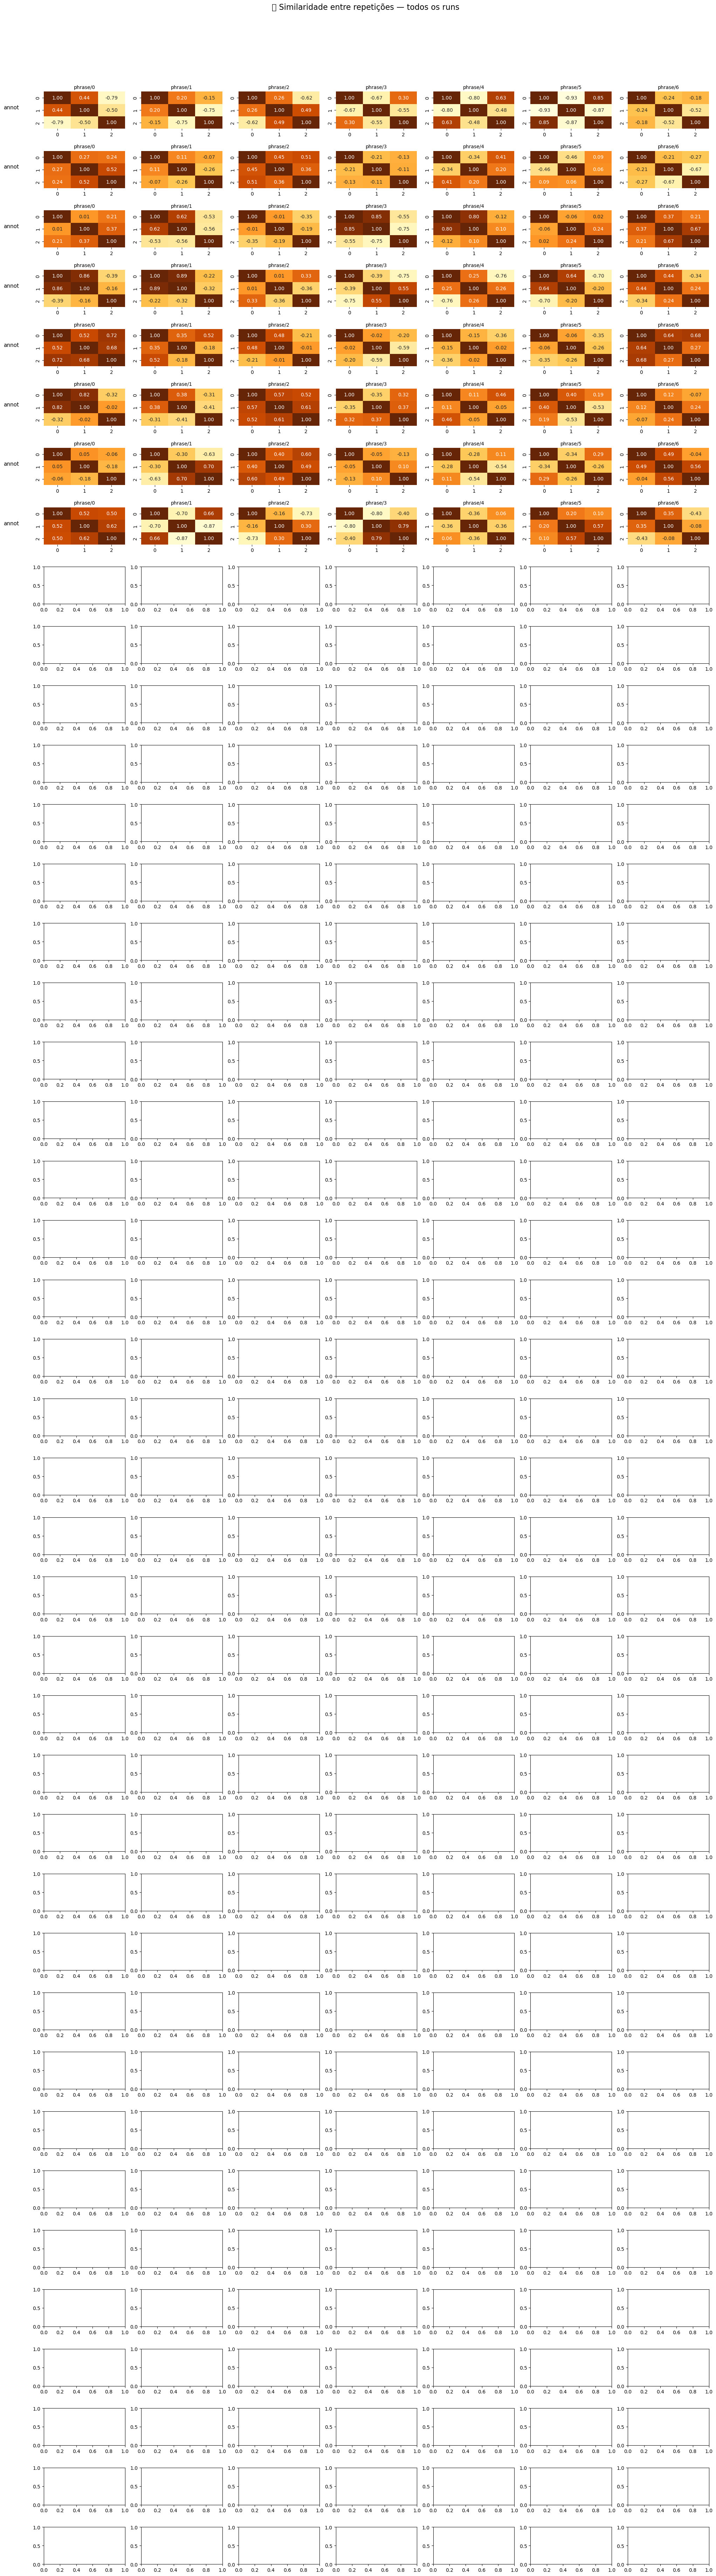

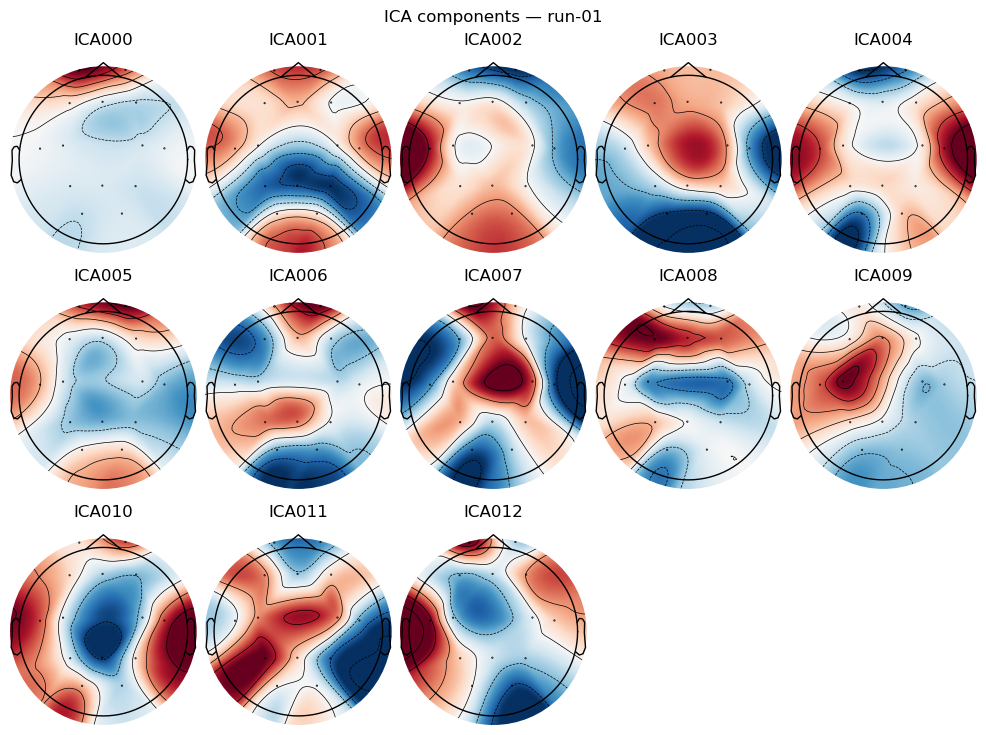

In [34]:
# Load the filtered and cropped run-01 block
fif_path = CONFIG["paths"]["filt_dir"] / "sub-lina_ses-02_task-musicphrases-sing_run-01_desc-filtcrop_eeg.fif"
raw = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)

# Apply common average reference if needed
raw.apply_proj()

# Run ICA without label_components()
ica = mne.preprocessing.ICA(
    n_components=CONFIG["ica"]["n_components"],
    method=CONFIG["ica"]["method"],
    random_state=CONFIG["ica"]["random_state"],
    max_iter=CONFIG["ica"]["max_iter"],
    fit_params=dict(ortho=False, extended=True),
)

ica.fit(raw, decim=CONFIG["ica"]["decim"], verbose="error")

# Plot ICA components for visual inspection
ica.plot_components(title="ICA components — run-01");


In [35]:
#ica.plot_sources(raw, show_scrollbars=True, title="ICA source signals — run-01")

In [36]:
# Setup
ica_dir = CONFIG["paths"]["ica_dir"]
filt_dir = CONFIG["paths"]["filt_dir"]
THRESH = 0.80
KEYWORDS = ("eye", "muscle", "heart", "line")  # artefact classes do ICLabel

# Lista de arquivos filtrados (igual ao notebook)
filt_paths = sorted(filt_dir.glob("sub-lina_ses-02_task-musicphrases-sing_run-*_desc-filtcrop_eeg.fif"))

# Escolher o primeiro bloco
raw = raw_blocks[0]
in_path = filt_paths[0]
stem = Path(in_path).stem.replace("_desc-filtcrop_eeg", "")
print(f"\n### Block {stem}: fitting ICA ...")

raw.apply_proj()

ica = mne.preprocessing.ICA(
    n_components=CONFIG["ica"]["n_components"],
    method=CONFIG["ica"]["method"],
    random_state=CONFIG["ica"]["random_state"],
    max_iter=CONFIG["ica"]["max_iter"],
    fit_params=dict(ortho=False, extended=True),
)
ica.fit(raw, decim=CONFIG["ica"]["decim"], verbose="error")

try:
    out = label_components(raw, ica, method="iclabel")
    labels = out["labels"]
    proba = np.asanyarray(out["y_pred_proba"])

    exclude_idx = []
    for i, lab in enumerate(labels):
        p = proba[i] if proba.ndim == 1 else proba[i].max()
        if any(kw in lab.lower() for kw in KEYWORDS) and p >= THRESH:
            exclude_idx.append(i)

    print(f"    ICLabel → excluding {exclude_idx}")

    if exclude_idx:
        ica.plot_components(picks=exclude_idx, title=f"{stem} – rejected ICs", show=True)

    ica.exclude = exclude_idx
    ica.apply(raw)
    raw.save(ica_dir / f"{stem}_desc-icaclean_eeg.fif", overwrite=True, verbose=False)
    ica.save(ica_dir / f"{stem}_ica.fif", overwrite=True, verbose=False)

except Exception as e:
    print(f"❌ Erro ao rodar ICLabel: {e}")



### Block sub-lina_ses-02_task-musicphrases-sing_run-01: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1802246004.py:28: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1802246004.py:28: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")


    ICLabel → excluding []
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (13 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components



### Block sub-lina_ses-02_task-musicphrases-sing_run-01: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")


    ICLabel → excluding []
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (13 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components

### Block sub-lina_ses-02_task-musicphrases-sing_run-02: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")


    ICLabel → excluding []
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (13 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components

### Block sub-lina_ses-02_task-musicphrases-sing_run-03: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


...

    ICLabel → excluding []
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (12 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components

### Block sub-lina_ses-02_task-musicphrases-sing_run-07: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")


    ICLabel → excluding []
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (12 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components

### Block sub-lina_ses-02_task-musicphrases-sing_run-08: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")


    ICLabel → excluding [4, 6]


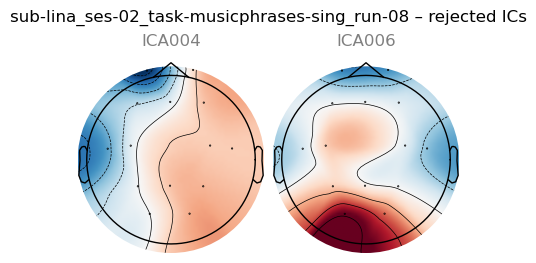

Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (12 components)
    Zeroing out 2 ICA components
    Projecting back using 14 PCA components

### Block sub-lina_ses-02_task-musicphrases-sing_run-09: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")


    ICLabel → excluding []
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (12 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components

### Block sub-lina_ses-02_task-musicphrases-sing_run-10: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")


    ICLabel → excluding []
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (12 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components

### Block sub-lina_ses-02_task-musicphrases-sing_run-11: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


...

    ICLabel → excluding []
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (12 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components

### Block sub-lina_ses-02_task-musicphrases-sing_run-20: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")


    ICLabel → excluding []
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (11 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components

### Block sub-lina_ses-02_task-musicphrases-sing_run-21: fitting ICA ...
Projections have already been applied. Setting proj attribute to True.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1266865103.py:31: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  out = label_components(raw, ica, method="iclabel")


    ICLabel → excluding []
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (12 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components

✅ ICA finished — all blocks labeled and saved (even clean ones).


In [37]:
# --- 1. Directory and parameter setup ---
ica_dir = CONFIG["paths"]["ica_dir"]
filt_dir = CONFIG["paths"]["filt_dir"]
THRESH = 0.80
KEYWORDS = ("eye", "muscle", "heart", "line")  # ICLabel artifact classes

# --- 2. List of filtered files ---
filt_paths = sorted(filt_dir.glob("sub-lina_ses-02_task-musicphrases-sing_run-*_desc-filtcrop_eeg.fif"))


# --- 4. Loop through filtered blocks ---
for raw, in_path in zip(raw_blocks, filt_paths):
    stem = Path(in_path).stem.replace("_desc-filtcrop_eeg", "")
    print(f"\n### Block {stem}: fitting ICA ...")

    raw.apply_proj()  # ensure CAR is on

    ica = mne.preprocessing.ICA(
        n_components=CONFIG["ica"]["n_components"],
        method=CONFIG["ica"]["method"],
        random_state=CONFIG["ica"]["random_state"],
        max_iter=CONFIG["ica"]["max_iter"],
        fit_params=dict(ortho=False, extended=True),
    )
    ica.fit(raw, decim=CONFIG["ica"]["decim"], verbose="error")

    # --- 5. Run ICLabel with timeout/fallback ---
    exclude_idx = []

    try:
        out = label_components(raw, ica, method="iclabel")
        labels = out["labels"]
        proba = np.asanyarray(out["y_pred_proba"])

        for i, lab in enumerate(labels):
            p = proba[i] if proba.ndim == 1 else proba[i].max()
            if any(kw in lab.lower() for kw in KEYWORDS) and p >= THRESH:
                exclude_idx.append(i)

        print(f"    ICLabel → excluding {exclude_idx}")

    except TimeoutError:
        print("⚠️ ICLabel skipped due to timeout.")
    except Exception as e:
        print(f"⚠️ ICLabel failed: {e}")

    # --- 6. Apply and save ICA (always) ---
    ica.exclude = exclude_idx
    if exclude_idx:
        ica.plot_components(picks=exclude_idx,
                            title=f"{stem} – rejected ICs", show=True)

    ica.apply(raw)

    raw.save(ica_dir / f"{stem}_desc-icaclean_eeg.fif", overwrite=True, verbose=False)
    ica.save(ica_dir / f"{stem}_ica.fif", overwrite=True, verbose=False)

print("\n✅ ICA finished — all blocks labeled and saved (even clean ones).")


## 3. Inspection of ICA results (example: blk8)

Below we reload both the fitted **ICA model** and the corresponding
**cleaned Raw** for *blk18* (the penultimate block) and:

1. Print a textual summary of which ICs were excluded and their labels.  
2. Display the topomaps of the rejected components and the “before vs after”
   butterfly plot so we can verify that eye / muscle artefacts are gone.


In [38]:
blk_idx = 1
run_str = f"run-{blk_idx+1:02d}"
stem = f"sub-lina_ses-02_task-musicphrases-sing_{run_str}"
ica_path = CONFIG["paths"]["ica_dir"] / f"{stem}_ica.fif"
raw_path = CONFIG["paths"]["ica_dir"] / f"{stem}_desc-icaclean_eeg.fif"

ica  = mne.preprocessing.read_ica(ica_path)
raw  = mne.io.read_raw_fif(raw_path, preload=True)  # just to know ch-names

print(f"=== {stem}  ICA summary ===")
print("Excluded IC indices :", ica.exclude)
try:
    print("ICLabel classes   :", ica.labels_)  # added by label_components
except AttributeError:
    print("No 'labels_' attr → ICLabel not run / not saved.")

print(f"Cleaned Raw shape  : {raw._data.shape}  (n_ch × n_samples)")


Reading /Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/ica_clean/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-02_ica.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 14) active
Now restoring ICA solution ...
Ready.
Opening raw data file ../bids_dataset/derivatives/ica_clean/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-02_desc-icaclean_eeg.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 14) active
    Range : 2857 ... 19482 =     22.856 ...   155.856 secs
Ready.
Reading 0 ... 16625  =      0.000 ...   133.000 secs...
=== sub-lina_ses-02_task-musicphrases-sing_run-02  ICA summary ===
Excluded IC indices : []
ICLabel classes   : {'brain': [2, 3, 4, 5, 7], 'muscle': [], 'eog': [0], 'ecg': [], 'line_noise': [], 'ch_noise': [], 'other': [1, 6, 8, 9, 10, 11, 12]}
Cleaned Raw shape  : (15, 16626)  (n_ch × n_samples)


In [39]:
# Visual sanity checks for run-19 (idx = 18)

# Use the same stem as previous cell
blk_idx = 18
run_str = f"run-{blk_idx+1:02d}"
stem = f"sub-lina_ses-02_task-musicphrases-sing_{run_str}"

# 1. Topomaps of rejected ICs
if ica.exclude:
    ica.plot_components(picks=ica.exclude,
                        title=f"{stem} – rejected ICs",
                        show=True)

# 2. Butterfly plots before vs. after ICA application
# Load original filtered/cropped (not ICA-cleaned yet)
orig_path = CONFIG["paths"]["filt_dir"] / f"{stem}_desc-filtcrop_eeg.fif"
raw_orig  = mne.io.read_raw_fif(orig_path, preload=True)

# Use the same visual scaling for before/after
scale = dict(eeg=2e-6)  # 2 µV/div, as previously defined

fig1 = raw_orig.plot(title=f"{stem} – BEFORE ICA  (2 µV/div)",
                     scalings=scale, show=True)

fig2 = ica.apply(raw_orig.copy(), exclude=ica.exclude)\
          .plot(title=f"{stem} – AFTER ICA  (2 µV/div)",
                scalings=scale, show=True)

plt.show()


Opening raw data file ../bids_dataset/derivatives/filt_crop/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-19_desc-filtcrop_eeg.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 14)  idle
    Range : 3257 ... 19882 =     26.056 ...   159.056 secs
Ready.
Reading 0 ... 16625  =      0.000 ...   133.000 secs...
Using pyopengl with version 3.1.9
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (13 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components
Using pyopengl with version 3.1.9


## 4. Injecting phrase targets as MNE Annotations

**Why here?**  
After ICA cleaning, we now mark the six lyrical phrases in each block  
(`phrase 0–6`) as **MNE Annotations**, preserving:

* the structure of the song,
* alignment to audio onsets,
* and a consistent marker format for epoching or modeling.

**How the annotations are derived**  
We use `audio-timeline.csv`, which contains three repetitions (`sequence1–3`)  
of the full song. Each row is a phrase (0–6), and each column is its end time  
within a sequence. Since all filtered blocks are already cropped to start at  
**sequence 1 (t = 0)** and last exactly **133 seconds**, we can align directly.

**Annotation strategy**

- `phrase/0` marks the *intro melody*  
- `phrase/1–6` mark the six lyrical segments  
- The annotations are stored directly inside the `.fif` and saved to  
  `derivatives/annotated/..._annot_raw.fif`


In [40]:
# Measure the duration of each ICA-cleaned block
durations = []

for f in sorted(CONFIG["paths"]["ica_dir"].glob("sub-lina_ses-02_task-musicphrases-sing_run-??_desc-icaclean_eeg.fif")):
    blk_id = f.stem[:5]
    raw    = mne.io.read_raw_fif(f, preload=False, verbose=False)
    dur_s  = raw.times[-1]
    durations.append({"block": blk_id, "seconds": round(dur_s, 2)})

df = pd.DataFrame(durations)
print(df.to_string(index=False))

print("\nSummary:")
print(df["seconds"].describe().to_string())


block  seconds
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0
sub-l    133.0

Summary:
count     21.0
mean     133.0
std        0.0
min      133.0
25%      133.0
50%      133.0
75%      133.0
max      133.0


In [41]:
# ⏱️ Annotate clean blocks with phrases 0–6 (safe version)

TMAX = 133.0  # max block duration
tl = pd.read_csv(CONFIG["paths"]["timing_csv"])

def hms2s(t):  # convert HH:MM:SS to seconds
    h, m, s = [float(x) for x in t.split(":")]
    return 3600 * h + 60 * m + s

# Convert all timeline values to seconds
for col in tl.columns[1:]:
    tl[col] = tl[col].apply(hms2s)

# phrase_end_times[phrase][sequence] = time (s)
phrase_end_times = {int(r["target"]): r[1:].tolist() for _, r in tl.iterrows()}

in_dir  = CONFIG["paths"]["ica_dir"]
out_dir = CONFIG["paths"]["annot_dir"]
out_dir.mkdir(parents=True, exist_ok=True)

fpaths = sorted(in_dir.glob("sub-lina_ses-02_task-musicphrases-sing_run-*_desc-icaclean_eeg.fif"))

for f_in in fpaths:
    stem = f_in.stem.replace("_desc-icaclean_eeg", "")
    raw = mne.io.read_raw_fif(f_in, preload=True, verbose=False)

    print(f"\n📄 Processing: {stem}")
    print("📌 Before:", raw.annotations)

    # Safely clear previous state
    raw.set_annotations(None)
    raw.set_meas_date(None)
    raw.crop(tmin=0.0, tmax=TMAX, include_tmax=True)

    # Create fresh annotations for this file
    ann = mne.Annotations(onset=[], duration=[], description=[])

    for seq in range(3):         # three repetitions
        for p in range(7):       # phrases 0–6
            # Onset = end of previous phrase (or 0.0 at beginning)
            if p == 0:
                onset = phrase_end_times[6][seq - 1] if seq > 0 else 0.0
            else:
                onset = phrase_end_times[p - 1][seq]

            end = phrase_end_times[p][seq]
            duration = end - onset

            # Check if annotation fits within block
            if onset >= raw.times[-1] or end > raw.times[-1]:
                print(f"⚠️ Skipped phrase/{p} in seq {seq}: outside of range ({onset:.2f} → {end:.2f})")
                continue

            ann.append(onset=onset, duration=duration, description=f"phrase/{p}")
            print(f"📝 phrase/{p} | seq {seq} | {onset:.2f}s → {end:.2f}s")

    raw.set_annotations(ann)
    print("✅ After:", raw.annotations)

    out_path = out_dir / f"{stem}_icaclean_annot.fif"
    raw.save(out_path, overwrite=True, verbose=False)

    print(f"💾 Saved: {out_path.name} — {len(ann)} annotations (last onset: {ann.onset[-1]:.2f}s)")

print("\n🎯 Finished — All annotations now correctly bounded by TMAX.")



📄 Processing: sub-lina_ses-02_task-musicphrases-sing_run-01
📌 Before: <Annotations | 0 segments>
📝 phrase/0 | seq 0 | 0.00s → 5.00s
📝 phrase/1 | seq 0 | 5.00s → 10.00s
📝 phrase/2 | seq 0 | 10.00s → 16.00s
📝 phrase/3 | seq 0 | 16.00s → 23.00s
📝 phrase/4 | seq 0 | 23.00s → 29.00s
📝 phrase/5 | seq 0 | 29.00s → 35.00s
📝 phrase/6 | seq 0 | 35.00s → 43.00s
📝 phrase/0 | seq 1 | 43.00s → 49.00s
📝 phrase/1 | seq 1 | 49.00s → 54.00s
📝 phrase/2 | seq 1 | 54.00s → 60.00s
📝 phrase/3 | seq 1 | 60.00s → 67.00s
📝 phrase/4 | seq 1 | 67.00s → 73.00s
📝 phrase/5 | seq 1 | 73.00s → 79.00s
📝 phrase/6 | seq 1 | 79.00s → 87.00s
📝 phrase/0 | seq 2 | 87.00s → 93.00s
📝 phrase/1 | seq 2 | 93.00s → 99.00s
📝 phrase/2 | seq 2 | 99.00s → 105.00s
📝 phrase/3 | seq 2 | 105.00s → 112.00s
📝 phrase/4 | seq 2 | 112.00s → 118.00s
📝 phrase/5 | seq 2 | 118.00s → 124.00s
📝 phrase/6 | seq 2 | 124.00s → 132.00s
✅ After: <Annotations | 21 segments: phrase/0 (3), phrase/1 (3), phrase/2 (3), ...>
💾 Saved: sub-lina_ses-02_task-music

/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1210662768.py:61: RuntimeWarning: This filename (/Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-01_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(out_path, overwrite=True, verbose=False)
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1210662768.py:61: RuntimeWarning: This filename (/Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-02_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fi

💾 Saved: sub-lina_ses-02_task-musicphrases-sing_run-21_icaclean_annot.fif — 21 annotations (last onset: 124.00s)

🎯 Finished — All annotations now correctly bounded by TMAX.


In [42]:
from mne.io import read_raw_fif
from pathlib import Path

# Get directory containing annotations
annot_dir = CONFIG["paths"]["annot_dir"]
fpaths = sorted(annot_dir.glob("*_icaclean_annot.fif"))

# Process each file (21 expected)
for idx, fpath in enumerate(fpaths, start=1):
    raw = read_raw_fif(fpath, preload=True, verbose=False)
    ann = raw.annotations

    if len(ann) == 0:
        print(f"⚠️ Block {idx:02d} — {fpath.name} has no annotations")
        continue

    # Timing and labels
    first_onset = ann.onset[0]
    last_end = ann.onset[-1] + ann.duration[-1]
    first_label = ann.description[0]
    last_label = ann.description[-1]

    # Signal window
    block_duration = raw.times[-1]
    data_start = first_onset
    data_end = data_start + block_duration

    # Print summary
    print(f"\n🧠 Block {idx:02d} — {fpath.name}")
    print(f"🟢 First annotation: onset={first_onset:.2f}s | label={first_label}")
    print(f"🔴 Last annotation:  ends at {last_end:.2f}s | label={last_label}")
    print(f"📏 Signal window:    {data_start:.2f}s → {data_end:.2f}s | duration={block_duration:.2f}s")
    print(f"🔢 Total annotations: {len(ann)}")

    # Boundary check
    if last_end > data_end:
        print(f"❌ OVERFLOW: annotation ends at {last_end:.2f}s (beyond {data_end:.2f}s)")
    else:
        print("✅ OK — annotations within bounds")



🧠 Block 01 — sub-lina_ses-02_task-musicphrases-sing_run-01_icaclean_annot.fif
🟢 First annotation: onset=25.55s | label=phrase/0
🔴 Last annotation:  ends at 157.55s | label=phrase/6
📏 Signal window:    25.55s → 158.55s | duration=133.00s
🔢 Total annotations: 21
✅ OK — annotations within bounds

🧠 Block 02 — sub-lina_ses-02_task-musicphrases-sing_run-02_icaclean_annot.fif
🟢 First annotation: onset=22.86s | label=phrase/0
🔴 Last annotation:  ends at 154.86s | label=phrase/6
📏 Signal window:    22.86s → 155.86s | duration=133.00s
🔢 Total annotations: 21
✅ OK — annotations within bounds

🧠 Block 03 — sub-lina_ses-02_task-musicphrases-sing_run-03_icaclean_annot.fif
🟢 First annotation: onset=30.66s | label=phrase/0
🔴 Last annotation:  ends at 162.66s | label=phrase/6
📏 Signal window:    30.66s → 163.66s | duration=133.00s
🔢 Total annotations: 21
✅ OK — annotations within bounds

🧠 Block 04 — sub-lina_ses-02_task-musicphrases-sing_run-04_icaclean_annot.fif
🟢 First annotation: onset=26.12s | l

/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/2971139836.py:10: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-01_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = read_raw_fif(fpath, preload=True, verbose=False)
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/2971139836.py:10: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-02_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = read_

In [43]:
# load an already annotated block
raw = mne.io.read_raw_fif(
    CONFIG["paths"]["annot_dir"] / "sub-lina_ses-02_task-musicphrases-sing_run-01_icaclean_annot.fif", preload=False)

# scale of 10 µV/div, starts at t=0 s, shows 30 s per screen
raw.plot(title="blk02 – annotations overlay",
         start=0, duration=30,
         scalings=dict(eeg=2e-6),
         block=True)     # pause cell until window is closed


Opening raw data file ../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-01_icaclean_annot.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 14) active
    Range : 3194 ... 19819 =     25.552 ...   158.552 secs
Ready.


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/4129355123.py:2: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-01_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(


Using pyopengl with version 3.1.9
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none


## 5. Exploratory Data Analysis (EDA)

🎧 Analisando: sub-lina_ses-02_task-musicphrases-sing_run-01_icaclean_annot.fif
🧠 EEG shape: (14, 16626) | Duração: 133.00s
phrase/0: 3 vetores
phrase/1: 3 vetores
phrase/2: 3 vetores
phrase/3: 3 vetores
phrase/4: 3 vetores
phrase/5: 3 vetores
phrase/6: 3 vetores


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/3790516463.py:13: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-01_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/3790516463.py:53: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


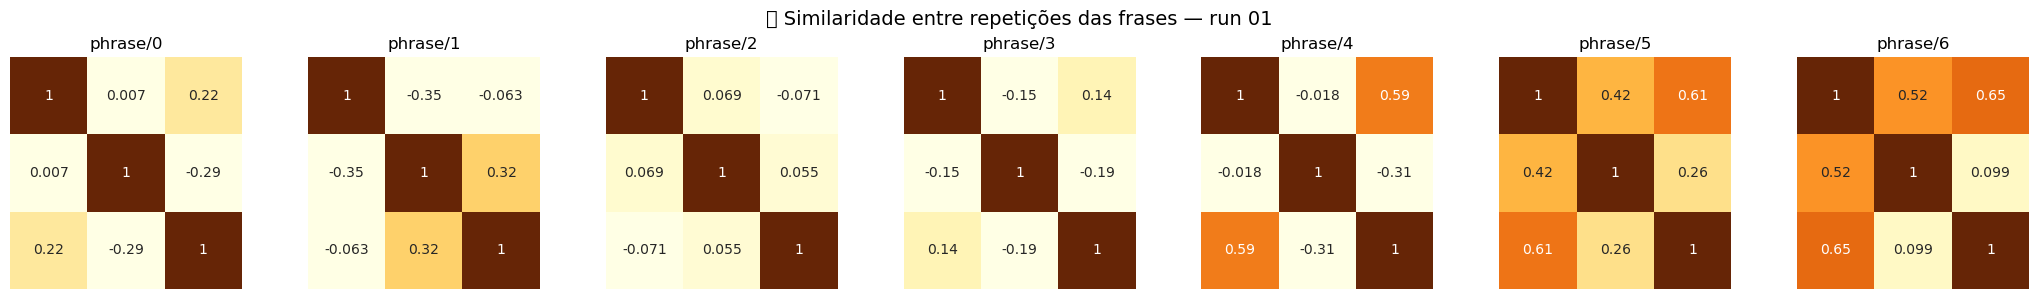

In [44]:
# 📍 Etapa 5.1 — Similaridade entre repetições da mesma frase em um mesmo bloco

from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import numpy as np
from collections import defaultdict

# 📁 Escolha o bloco que deseja analisar
run = 1  # Altere para o número do run desejado
fpath = sorted(CONFIG["paths"]["annot_dir"].glob(f"*run-{run:02d}*_annot.fif"))[0]
raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
print(f"🎧 Analisando: {fpath.name}")
print(f"🧠 EEG shape: {raw.get_data(picks='eeg').shape} | Duração: {raw.times[-1]:.2f}s")

# 🎯 Inicializa dicionário de vetores por frase
rep_vectors = defaultdict(list)

# 🔍 Itera pelas anotações e extrai média temporal por canal
for ann in raw.annotations:
    phrase = ann['description']
    tmin = ann['onset'] - raw.annotations.onset[0]
    tmax = tmin + ann['duration']
    try:
        data = raw.copy().crop(tmin, tmax).get_data(picks="eeg")  # shape: (n_channels, n_times)
        vec = data.mean(axis=1)  # média ao longo do tempo → shape: (n_channels,)
        rep_vectors[phrase].append(vec)
    except Exception as e:
        print(f"⚠️ Falha ao extrair {phrase} @ {tmin:.2f}s → {tmax:.2f}s: {e}")

# 📦 Verifica quantos vetores foram extraídos por frase
for phrase, vecs in rep_vectors.items():
    print(f"{phrase}: {len(vecs)} vetores")

# 📊 Plota matriz de similaridade para cada frase com 3 repetições
fig, axes = plt.subplots(1, len(rep_vectors), figsize=(3 * len(rep_vectors), 3))

if len(rep_vectors) == 1:
    axes = [axes]

for ax, (phrase, vecs) in zip(axes, sorted(rep_vectors.items())):
    if len(vecs) != 3:
        ax.axis("off")
        ax.set_title(f"{phrase} (incompleto)")
        continue
    sims = cosine_similarity(vecs)
    sns.heatmap(sims, annot=True, vmin=0, vmax=1, square=True, cbar=False, ax=ax,
                cmap="YlOrBr", xticklabels=False, yticklabels=False)
    ax.set_title(f"{phrase}")

fig.suptitle(f"🔍 Similaridade entre repetições das frases — run {run:02d}", fontsize=14)
plt.tight_layout()
plt.show()


In [46]:
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import numpy as np
import mne

# 🧾 Armazena os resultados no dicionário final (mas imprime formatado)
all_similarities = {}

# 🌀 Itera sobre os 21 blocos (runs)
for run in range(1, 22):
    run_key = f"run{run:02d}"
    all_similarities[run_key] = {}

    fpath = sorted(CONFIG["paths"]["annot_dir"].glob(f"*run-{run:02d}*_annot.fif"))[0]
    raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
    eeg = raw.get_data(picks="eeg")

    # Inicializa dicionário de vetores por frase
    rep_vectors = defaultdict(list)

    for ann in raw.annotations:
        phrase = ann["description"]
        tmin = ann["onset"] - raw.annotations.onset[0]
        tmax = tmin + ann["duration"]
        try:
            data = raw.copy().crop(tmin, tmax).get_data(picks="eeg")
            vec = data.mean(axis=1)
            rep_vectors[phrase].append(vec)
        except Exception as e:
            continue

    print(f"\n🧠 {run_key}")
    for phrase in sorted(rep_vectors):
        vecs = rep_vectors[phrase]
        if len(vecs) == 3:
            sims = cosine_similarity(vecs)
            all_similarities[run_key][phrase] = sims.tolist()
            sim_vals = [round(sims[i, j], 2) for i in range(3) for j in range(i+1, 3)]
            print(f"  {phrase}: {sim_vals}")
        else:
            all_similarities[run_key][phrase] = None
            print(f"  {phrase}: ❌ incompleto ({len(vecs)} vetores)")


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/3172489301.py:15: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-01_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/3172489301.py:15: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-02_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw 


🧠 run01
  phrase/0: [0.01, 0.22, -0.29]
  phrase/1: [-0.35, -0.06, 0.32]
  phrase/2: [0.07, -0.07, 0.06]
  phrase/3: [-0.15, 0.14, -0.19]
  phrase/4: [-0.02, 0.59, -0.31]
  phrase/5: [0.42, 0.61, 0.26]
  phrase/6: [0.52, 0.65, 0.1]

🧠 run02
  phrase/0: [0.55, 0.45, 0.31]
  phrase/1: [-0.25, -0.5, 0.25]
  phrase/2: [-0.17, -0.64, 0.57]
  phrase/3: [0.41, -0.48, 0.11]
  phrase/4: [0.05, -0.44, -0.6]
  phrase/5: [-0.04, -0.32, -0.27]
  phrase/6: [0.53, 0.18, -0.08]

🧠 run03
  phrase/0: [0.42, 0.14, 0.28]
  phrase/1: [-0.12, 0.12, 0.59]
  phrase/2: [-0.09, -0.44, 0.76]
  phrase/3: [-0.41, -0.64, 0.52]
  phrase/4: [-0.06, 0.04, 0.34]
  phrase/5: [-0.27, 0.17, -0.36]
  phrase/6: [-0.32, -0.62, 0.55]

🧠 run04
  phrase/0: [0.75, -0.26, -0.57]
  phrase/1: [0.56, 0.76, 0.33]
  phrase/2: [-0.54, 0.38, -0.05]
  phrase/3: [-0.06, 0.59, 0.06]
  phrase/4: [0.27, 0.5, 0.33]
  phrase/5: [-0.67, 0.17, -0.25]
  phrase/6: [-0.46, -0.04, -0.7]

🧠 run05
  phrase/0: [0.2, -0.14, 0.34]
  phrase/1: [0.05, 0.4

/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/3172489301.py:15: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-07_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/3172489301.py:15: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-08_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw 


🧠 run07
  phrase/0: [0.81, 0.64, 0.79]
  phrase/1: [0.72, 0.67, 0.86]
  phrase/2: [-0.57, -0.47, 0.35]
  phrase/3: [-0.09, 0.15, 0.08]
  phrase/4: [-0.03, -0.07, -0.19]
  phrase/5: [-0.0, 0.23, 0.44]
  phrase/6: [0.07, 0.3, -0.07]

🧠 run08
  phrase/0: [0.39, -0.47, -0.71]
  phrase/1: [0.37, -0.6, -0.38]
  phrase/2: [0.18, -0.57, -0.64]
  phrase/3: [-0.19, 0.17, -0.07]
  phrase/4: [0.21, -0.15, -0.87]
  phrase/5: [-0.32, 0.01, -0.78]
  phrase/6: [-0.13, -0.34, 0.48]

🧠 run09
  phrase/0: [0.04, -0.07, 0.63]
  phrase/1: [-0.19, -0.63, 0.35]
  phrase/2: [0.54, 0.31, 0.45]
  phrase/3: [0.21, -0.16, 0.47]
  phrase/4: [-0.11, -0.2, 0.1]
  phrase/5: [0.11, -0.23, 0.47]
  phrase/6: [-0.08, -0.04, 0.33]

🧠 run10
  phrase/0: [-0.13, 0.01, -0.76]
  phrase/1: [0.58, -0.48, -0.53]
  phrase/2: [0.58, -0.3, -0.33]
  phrase/3: [0.41, -0.3, -0.73]
  phrase/4: [0.59, -0.21, -0.61]
  phrase/5: [0.26, 0.08, 0.5]
  phrase/6: [0.05, -0.71, -0.08]

🧠 run11
  phrase/0: [-0.01, -0.04, -0.08]
  phrase/1: [0.02,

/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/3172489301.py:15: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-13_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/3172489301.py:15: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-14_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw 


🧠 run13
  phrase/0: [-0.51, -0.11, 0.05]
  phrase/1: [0.25, 0.37, 0.52]
  phrase/2: [-0.05, -0.01, -0.27]
  phrase/3: [-0.39, 0.2, -0.56]
  phrase/4: [-0.2, 0.44, 0.31]
  phrase/5: [-0.07, -0.21, 0.41]
  phrase/6: [0.62, -0.73, -0.8]

🧠 run14
  phrase/0: [-0.44, 0.13, 0.53]
  phrase/1: [0.23, 0.08, 0.57]
  phrase/2: [0.67, 0.26, 0.64]
  phrase/3: [0.71, 0.27, 0.45]
  phrase/4: [0.37, -0.37, -0.3]
  phrase/5: [-0.8, 0.02, -0.04]
  phrase/6: [-0.77, 0.4, -0.2]

🧠 run15
  phrase/0: [0.3, -0.31, -0.79]
  phrase/1: [0.68, 0.32, 0.48]
  phrase/2: [0.42, 0.27, 0.27]
  phrase/3: [0.11, -0.39, -0.74]
  phrase/4: [0.34, -0.45, -0.92]
  phrase/5: [0.21, -0.5, -0.61]
  phrase/6: [-0.5, -0.33, 0.81]

🧠 run16
  phrase/0: [-0.05, -0.7, 0.13]
  phrase/1: [0.3, -0.04, -0.2]
  phrase/2: [-0.29, 0.07, -0.35]
  phrase/3: [-0.16, 0.73, -0.15]
  phrase/4: [-0.63, 0.88, -0.63]
  phrase/5: [-0.76, 0.88, -0.61]
  phrase/6: [0.0, 0.53, -0.24]

🧠 run17
  phrase/0: [-0.62, -0.04, -0.0]
  phrase/1: [-0.26, 0.33, 

/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/3172489301.py:15: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-19_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/3172489301.py:15: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-20_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw 

In [48]:
def phrase_stats(raw, n_samples=250):
    from collections import defaultdict
    phrase_data = defaultdict(list)
    sfreq = raw.info['sfreq']

    for onset, duration, desc in zip(raw.annotations.onset,
                                     raw.annotations.duration,
                                     raw.annotations.description):
        if desc.startswith("phrase/"):
            phrase = desc.split("/")[1]
            stop = onset + duration
            if stop > raw.times[-1]:
                continue
            segment = raw.copy().crop(tmin=onset, tmax=stop).get_data(picks="eeg")
            current = segment.shape[1]
            if current > n_samples:
                segment = segment[:, :n_samples]
            elif current < n_samples:
                pad = np.zeros((segment.shape[0], n_samples - current))
                segment = np.concatenate([segment, pad], axis=1)
            phrase_data[phrase].append(segment)

    # Statistics per phrase
    stats = {}
    for phrase, segments in phrase_data.items():
        arr = np.stack(segments)  # (n_seq, n_ch, n_time)
        mean = arr.mean()
        std  = arr.std()
        vmin = arr.min()
        vmax = arr.max()
        stats[phrase] = dict(mean=mean, std=std, min=vmin, max=vmax)

    return stats

# --- Use in blocks 2 and 21 (remember: Python index starts at 0)
raw1  = read_raw_fif(CONFIG["paths"]["annot_dir"] / "sub-lina_ses-02_task-musicphrases-sing_run-02_icaclean_annot.fif", preload=True)
raw21 = read_raw_fif(CONFIG["paths"]["annot_dir"] / "sub-lina_ses-02_task-musicphrases-sing_run-21_icaclean_annot.fif", preload=True)

stats1 = phrase_stats(raw1)
stats21 = phrase_stats(raw21)

# --- Print comparison
import pandas as pd

df = pd.DataFrame.from_dict(stats1, orient='index')
df.columns = [f"{col}_run02" for col in df.columns]

df2 = pd.DataFrame.from_dict(stats21, orient='index')
df2.columns = [f"{col}_run21" for col in df2.columns]

comparison = pd.concat([df, df2], axis=1)
display(comparison)


Opening raw data file ../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-02_icaclean_annot.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 14) active
    Range : 2857 ... 19482 =     22.856 ...   155.856 secs
Ready.
Reading 0 ... 16625  =      0.000 ...   133.000 secs...
Opening raw data file ../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-21_icaclean_annot.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 14) active
    Range : 4608 ... 21233 =     36.864 ...   169.864 secs
Ready.
Reading 0 ... 16625  =      0.000 ...   133.000 secs...


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/201396372.py:36: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-02_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw1  = read_raw_fif(CONFIG["paths"]["annot_dir"] / "sub-lina_ses-02_task-musicphrases-sing_run-02_icaclean_annot.fif", preload=True)
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/201396372.py:37: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-21_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fi

,mean_run02,std_run02,min_run02,max_run02,mean_run21,std_run21,min_run21,max_run21
0,-1.235715e-16,2.164841e-07,-1.185976e-06,8.529269e-07,6.032691e-17,1.879691e-07,-7.823762e-07,7.030718e-07
1,-1.005690e-16,2.306146e-07,-1.454203e-06,8.746398e-07,1.992751e-17,2.377843e-07,-9.140098e-07,1.201006e-06
2,-1.284564e-16,2.258033e-07,-1.286221e-06,8.184953e-07,2.320064e-16,2.370249e-07,-1.199518e-06,1.169893e-06
3,-2.794001e-17,2.376802e-07,-8.272795e-07,8.406781e-07,1.123119e-16,2.215069e-07,-1.448925e-06,7.589605e-07
4,-1.294369e-16,2.984000e-07,-1.466887e-06,1.114525e-06,-3.623038e-17,1.999604e-07,-9.973212e-07,6.981633e-07
5,-9.363319e-17,2.243088e-07,-1.455740e-06,7.938725e-07,-1.441988e-16,2.293190e-07,-1.114498e-06,6.766647e-07
6,8.909738e-17,1.913604e-07,-9.690878e-07,6.768543e-07,6.115049e-17,1.924084e-07,-8.450487e-07,8.034334e-07


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1518211268.py:42: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-02_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = read_raw_fif(fpath, preload=True, verbose=False)
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1518211268.py:42: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-21_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = read_

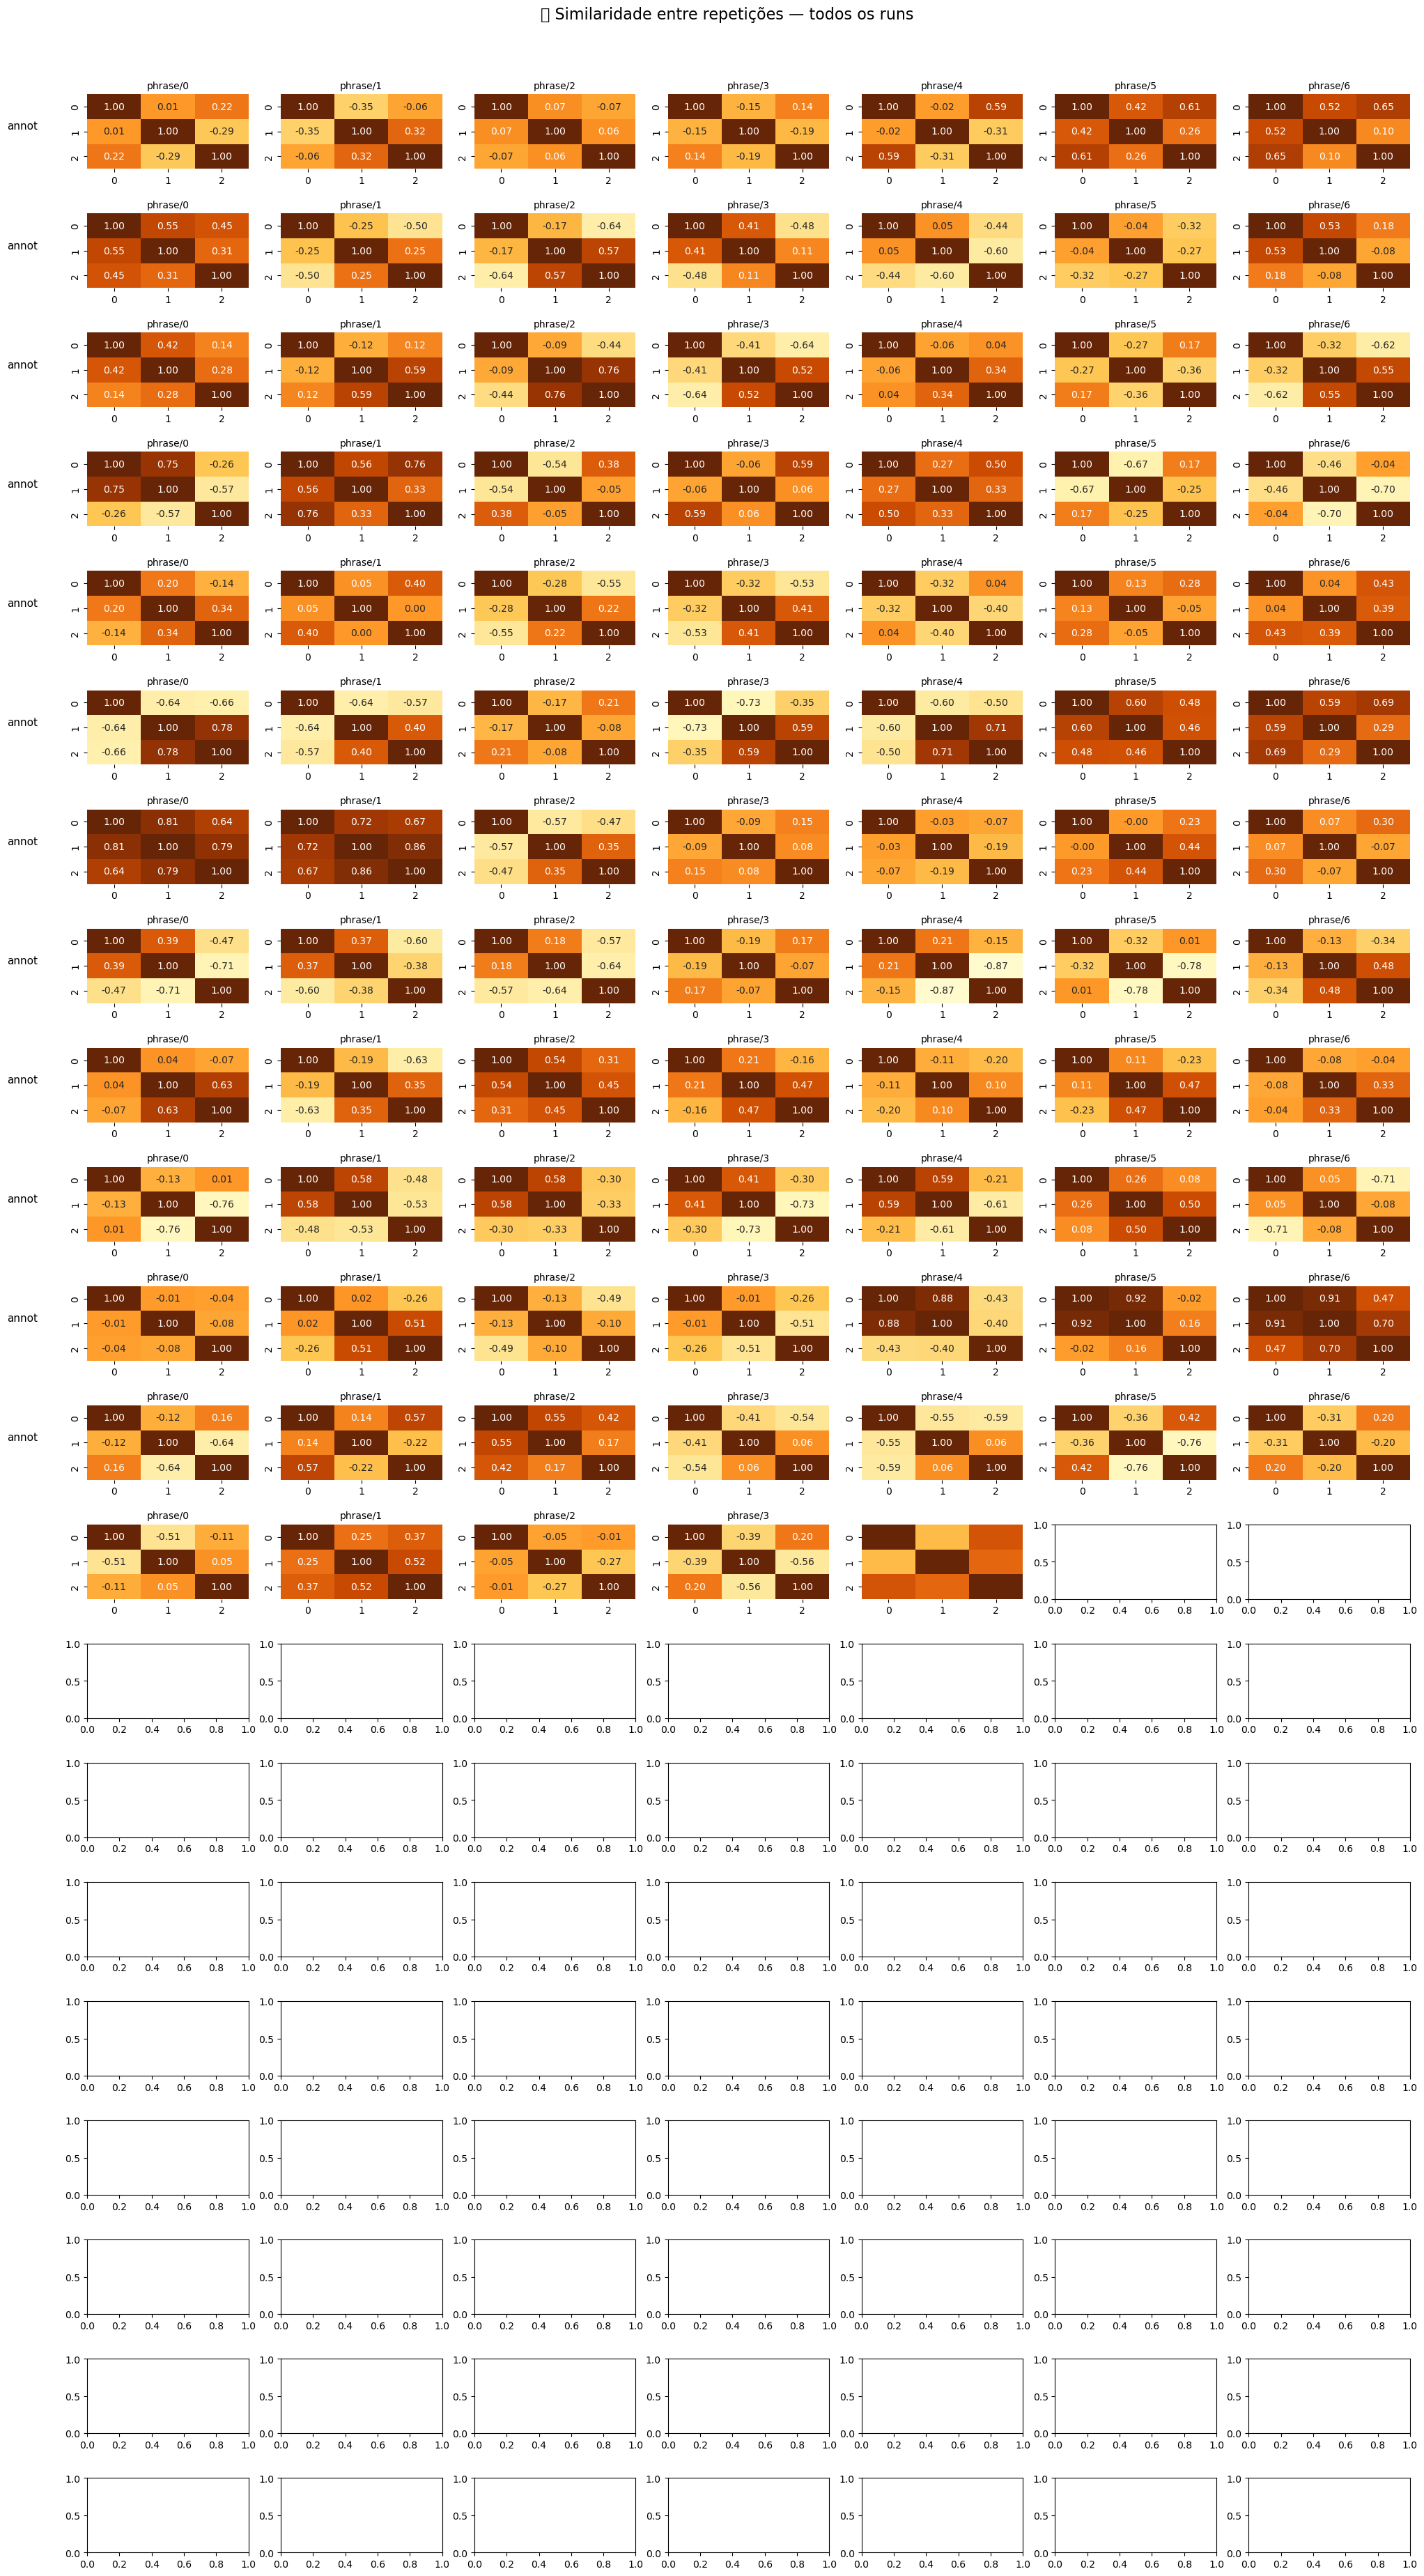

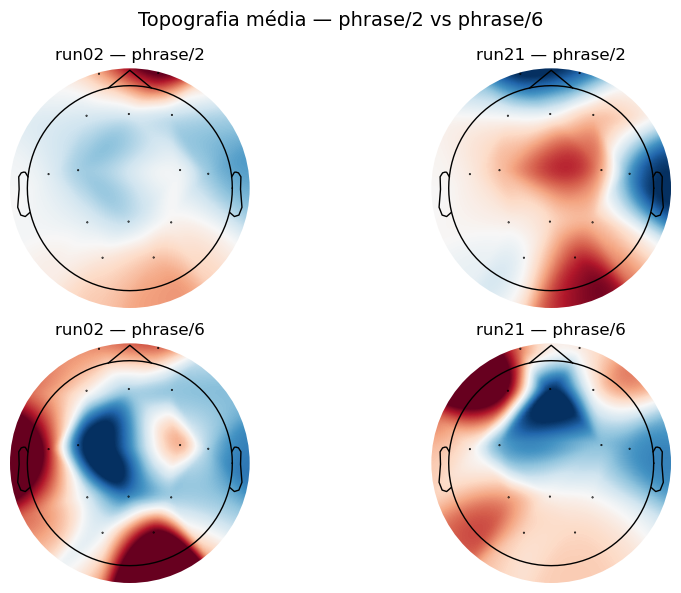

In [49]:
from mne.io import read_raw_fif
from mne.viz import plot_topomap
import numpy as np
import matplotlib.pyplot as plt

# --- Caminho base ---
paths = CONFIG["paths"]["annot_dir"]

# --- Blocos escolhidos ---
files = {
    "run02": paths / "sub-lina_ses-02_task-musicphrases-sing_run-02_icaclean_annot.fif",
    "run21": paths / "sub-lina_ses-02_task-musicphrases-sing_run-21_icaclean_annot.fif"
}

# --- Frases a comparar ---
target_phrases = ["phrase/2", "phrase/6"]

# --- Função para média por canal de todas ocorrências da frase ---
def compute_phrase_topo(raw, phrase):
    picks = raw.copy().pick("eeg")
    data_list = []

    for ann in raw.annotations:
        if ann["description"] == phrase:
            tmin = ann["onset"]
            tmax = min(tmin + ann["duration"], raw.times[-1])
            if tmax > tmin:
                cropped = picks.copy().crop(tmin=tmin, tmax=tmax)
                data = cropped.get_data()
                data_list.append(data.mean(axis=1))  # média por canal

    if not data_list:
        return None

    return np.mean(data_list, axis=0)

# --- Processamento e plot ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
fig.suptitle("Topografia média — phrase/2 vs phrase/6", fontsize=14)

for col, (run_label, fpath) in enumerate(files.items()):
    raw = read_raw_fif(fpath, preload=True, verbose=False)

    for row, phrase in enumerate(target_phrases):
        topo = compute_phrase_topo(raw, phrase)

        if topo is not None:
            plot_topomap(
                topo, raw.info, axes=axes[row, col],
                show=False, contours=0, sphere=0.09
            )
            axes[row, col].set_title(f"{run_label} — {phrase}")
        else:
            axes[row, col].text(0.5, 0.5, "no data", ha="center", va="center")

plt.tight_layout()
plt.show()


In [50]:
from sklearn.preprocessing import normalize

# Coletar vetores topográficos para todas as frases de um bloco
def get_topo_vectors(raw, phrases):
    vectors = {}
    for phrase in phrases:
        vec = compute_phrase_topo(raw, phrase)
        if vec is not None:
            vectors[phrase] = normalize(vec.reshape(1, -1), norm="l2")[0]  # normaliza L2
    return vectors

# Carregar os dois blocos
raws = {
    run_label: read_raw_fif(fpath, preload=True, verbose=False)
    for run_label, fpath in files.items()
}

# Aplicar para frases 0 a 6
phrases = [f"phrase/{i}" for i in range(7)]
vectors_per_run = {
    run_label: get_topo_vectors(raw, phrases)
    for run_label, raw in raws.items()
}


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1275927181.py:14: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-02_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  run_label: read_raw_fif(fpath, preload=True, verbose=False)
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_69662/1275927181.py:14: RuntimeWarning: This filename (../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-21_icaclean_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  run_la

In [52]:
import pandas as pd

# Criar matriz frase_i (run02) vs frase_j (run21)
sim_matrix = pd.DataFrame(index=phrases, columns=phrases)

for p1 in phrases:
    for p2 in phrases:
        v1 = vectors_per_run["run02"].get(p1)
        v2 = vectors_per_run["run21"].get(p2)
        if v1 is not None and v2 is not None:
            sim_matrix.loc[p1, p2] = np.dot(v1, v2)
        else:
            sim_matrix.loc[p1, p2] = np.nan


<Figure size 800x600 with 0 Axes>

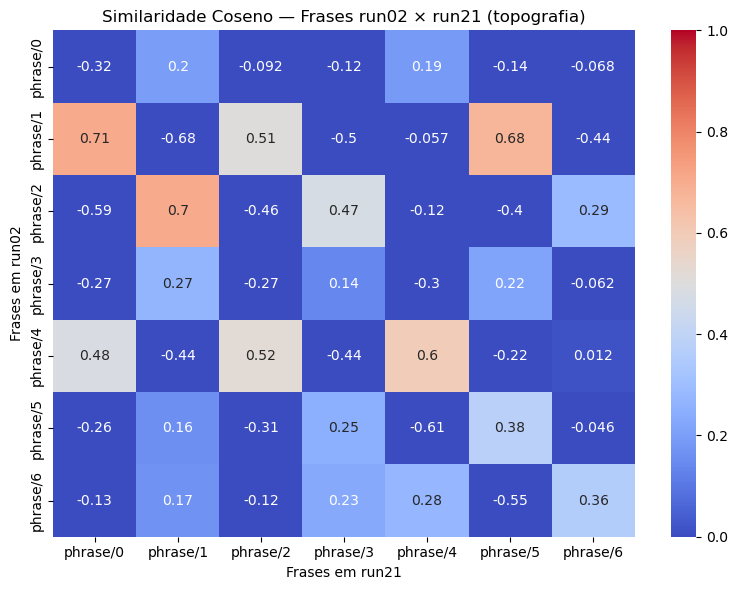

: 

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix.astype(float), annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Similaridade Coseno — Frases run02 × run21 (topografia)")
plt.xlabel("Frases em run21")
plt.ylabel("Frases em run02")
plt.tight_layout()
plt.show()
